# Forecasting Exchange Rates Using Time Series Analysis

## Objective

Leverage ARIMA and Exponential Smoothing techniques to forecast future exchange rates based on historical data.

## Dataset

The dataset contains historical exchange rates over time. The first column represents the date, and the second column represents the USD to Australian Dollar exchange rate.

## Part 1: Data Preparation and Exploration

### Question 1: Data Loading

Load the exchange_rate.csv dataset and parse the date column appropriately.

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the exchange rate dataset
df = pd.read_csv("exchange_rate.csv")

# Display the first five rows
df.head()


,date,Ex_rate
0,01-01-1990 00:00,0.7855
1,02-01-1990 00:00,0.7818
2,03-01-1990 00:00,0.7867
3,04-01-1990 00:00,0.7860
4,05-01-1990 00:00,0.7849


In [43]:
# Convert the date column to datetime format
df["date"] = pd.to_datetime(df["date"], format="%d-%m-%Y %H:%M")

# Check the data types
print(df.dtypes)

# Display the first five rows
df.head()

date       datetime64[us]
Ex_rate           float64
dtype: object


,date,Ex_rate
0,1990-01-01,0.7855
1,1990-01-02,0.7818
2,1990-01-03,0.7867
3,1990-01-04,0.7860
4,1990-01-05,0.7849


## Question 2: Initial Exploration

Plot the time series for the exchange rate to understand its trends, seasonality, and any anomalies.

In [44]:
# Display basic information about the dataset
print("Dataset shape:", df.shape)

print("\nDataset information:")
df.info()

print("\nDescriptive statistics:")
display(df.describe())

Dataset shape: (7588, 2)

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 7588 entries, 0 to 7587
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   date     7588 non-null   datetime64[us]
 1   Ex_rate  7588 non-null   float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 118.7 KB

Descriptive statistics:


,date,Ex_rate
count,7588,7588.000000
mean,2000-05-21 12:00:00,0.776974
min,1990-01-01 00:00:00,0.483297
25%,1995-03-12 18:00:00,0.701422
50%,2000-05-21 12:00:00,0.761377
75%,2005-07-31 06:00:00,0.873477
max,2010-10-10 00:00:00,1.102536
std,NaN,0.136620


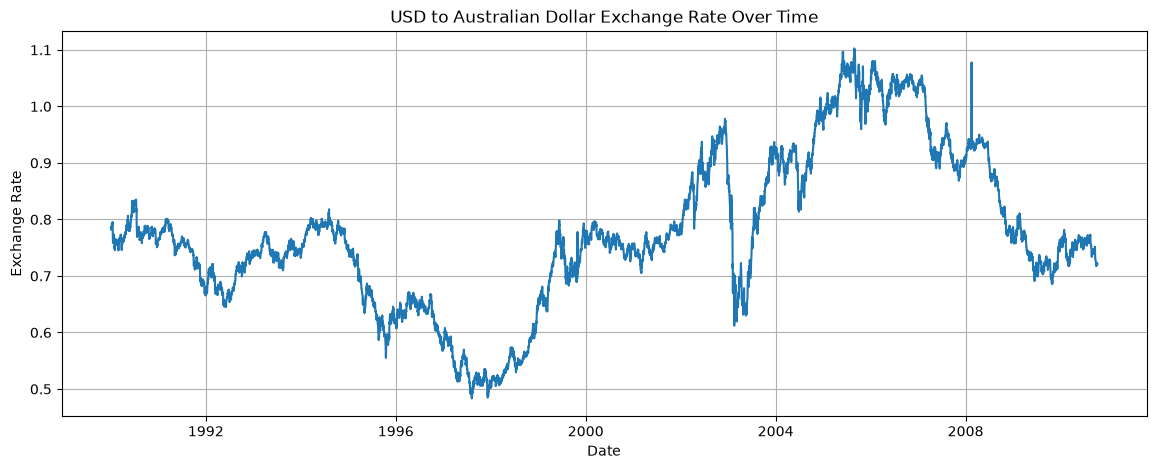

In [45]:
# Plot the exchange rate over time
plt.figure(figsize=(14, 5))

plt.plot(df["date"], df["Ex_rate"])

plt.title("USD to Australian Dollar Exchange Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")

plt.grid(True)
plt.show()

## Question 3: Data Preprocessing

Handle missing values or anomalies identified during the exploration phase.

Missing values will be handled using forward fill (`ffill`) as required.

In [46]:
# Check for missing values before handling them
print("Missing values before forward fill:")
print(df.isnull().sum())

Missing values before forward fill:
date       0
Ex_rate    0
dtype: int64


In [47]:
# Handle missing values using forward fill
df["Ex_rate"] = df["Ex_rate"].ffill()

# Check for missing values after forward fill
print("Missing values after forward fill:")
print(df.isnull().sum())

Missing values after forward fill:
date       0
Ex_rate    0
dtype: int64


In [48]:
# Display the first five rows after preprocessing
df.head()

,date,Ex_rate
0,1990-01-01,0.7855
1,1990-01-02,0.7818
2,1990-01-03,0.7867
3,1990-01-04,0.7860
4,1990-01-05,0.7849


## Stationarity Testing

Before applying the ARIMA model, we need to check whether the exchange rate time series is stationary.

The Augmented Dickey-Fuller (ADF) test will be used to test for stationarity.

In [49]:
# Interpret the ADF test result

if adf_result[1] < 0.05:
    print("The time series is stationary.")
else:
    print("The time series is not stationary and requires differencing.")

The time series is not stationary and requires differencing.


## Differencing

Since the original exchange rate series is not stationary, first-order differencing is applied to make the series stationary.

In [50]:
# Apply first-order differencing
df["Ex_rate_diff"] = df["Ex_rate"].diff()

# Remove the first NaN value created by differencing
diff_series = df["Ex_rate_diff"].dropna()

# Display the first few differenced values
diff_series.head()

1   -0.0037
2    0.0049
3   -0.0007
4   -0.0011
5    0.0017
Name: Ex_rate_diff, dtype: float64

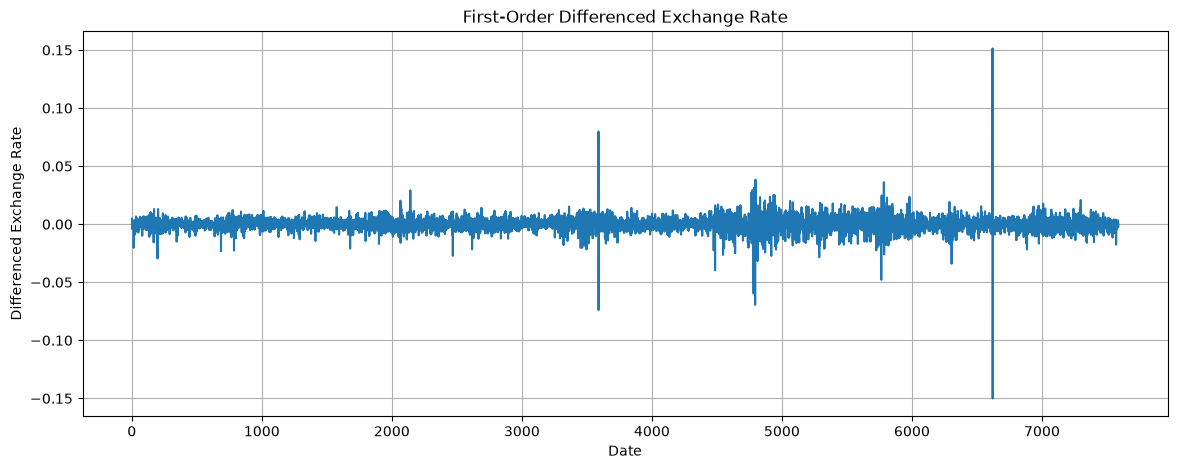

In [51]:
# Plot the differenced exchange rate

plt.figure(figsize=(14, 5))

plt.plot(diff_series)

plt.title("First-Order Differenced Exchange Rate")
plt.xlabel("Date")
plt.ylabel("Differenced Exchange Rate")

plt.grid(True)
plt.show()

In [52]:
# Interpret the ADF test after differencing

if adf_diff_result[1] < 0.05:
    print("The differenced time series is stationary.")
else:
    print("The differenced time series is still not stationary.")

The differenced time series is stationary.


## ARIMA Parameter Selection

### ACF and PACF Analysis

The ACF and PACF plots of the stationary, first-differenced series are used to estimate suitable initial values for the ARIMA parameters (p, d, q).

In [53]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

<Figure size 1200x500 with 0 Axes>

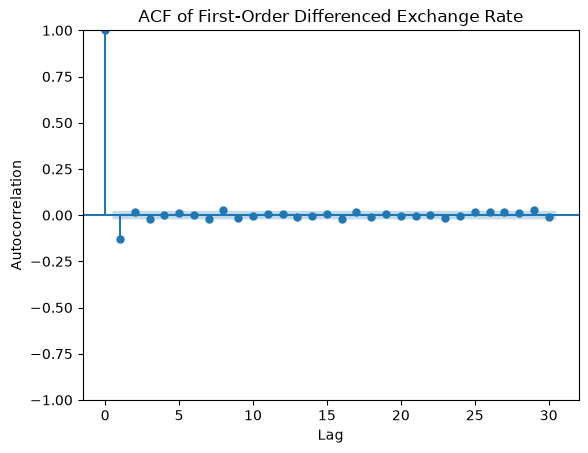

In [54]:
# Plot ACF for the differenced series

plt.figure(figsize=(12, 5))

plot_acf(diff_series, lags=30)

plt.title("ACF of First-Order Differenced Exchange Rate")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")

plt.show()

<Figure size 1200x500 with 0 Axes>

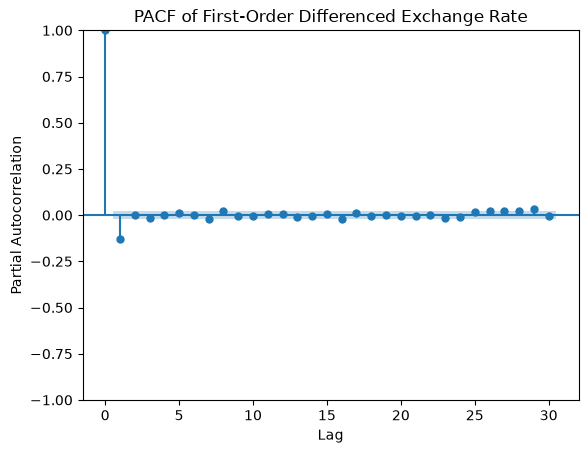

In [55]:
# Plot PACF for the differenced series

plt.figure(figsize=(12, 5))

plot_pacf(diff_series, lags=30, method="ywm")

plt.title("PACF of First-Order Differenced Exchange Rate")
plt.xlabel("Lag")
plt.ylabel("Partial Autocorrelation")

plt.show()

### ARIMA Parameter Selection

The ACF and PACF plots of the first-order differenced series show a noticeable autocorrelation at the first lag, while most higher-order lags remain close to zero.

Based on the stationarity test, first-order differencing is required, so d = 1. The ACF and PACF plots indicate that a low-order ARIMA model is appropriate.

Therefore, ARIMA(1,1,1) is selected as the initial model for forecasting.

## Part 2: Model Building - ARIMA

### Model Fitting

The ARIMA(1,1,1) model is fitted to the preprocessed exchange rate time series.

In [56]:
from statsmodels.tsa.arima.model import ARIMA

# Define the ARIMA order
p = 1
d = 1
q = 1

# Fit the ARIMA model
arima_model = ARIMA(df["Ex_rate"], order=(p, d, q))
arima_result = arima_model.fit()

# Display the model summary
print(arima_result.summary())

                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 7588
Model:                 ARIMA(1, 1, 1)   Log Likelihood               28054.161
Date:                Fri, 28 Aug 2026   AIC                         -56102.322
Time:                        10:35:54   BIC                         -56081.519
Sample:                             0   HQIC                        -56095.182
                               - 7588                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1268      0.045     -2.797      0.005      -0.216      -0.038
ma.L1         -0.0046      0.045     -0.101      0.920      -0.094       0.085
sigma2      3.596e-05   9.94e-08    361.604      0.0

### ARIMA Residual Diagnostics

Residual diagnostics are performed to check whether the ARIMA model has captured the important patterns in the time series.

In [57]:
# Extract ARIMA residuals
residuals = arima_result.resid

# Display basic residual statistics
print("Residual Mean:", residuals.mean())
print("Residual Standard Deviation:", residuals.std())

Residual Mean: 9.387036879972666e-05
Residual Standard Deviation: 0.01082923341998784


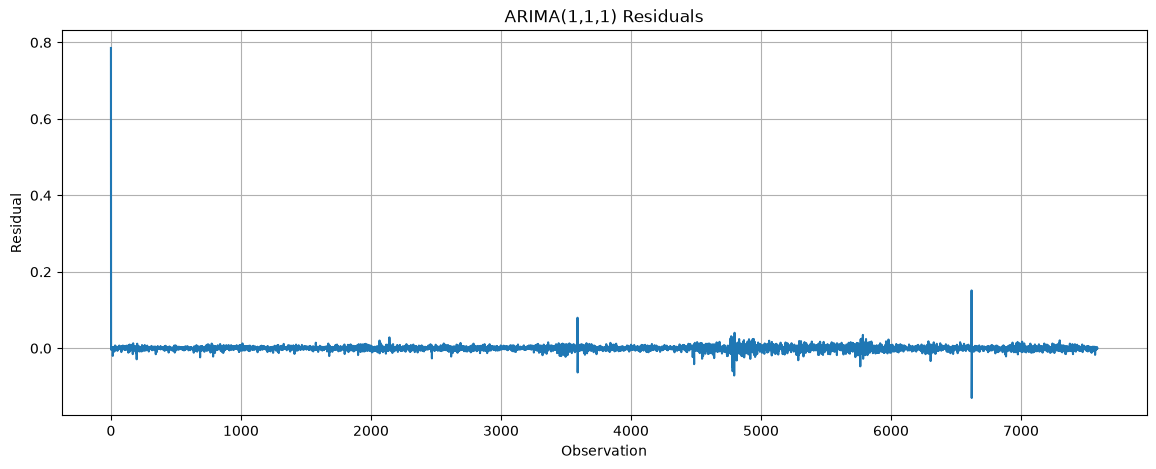

In [58]:
# Plot ARIMA residuals

plt.figure(figsize=(14, 5))

plt.plot(residuals)

plt.title("ARIMA(1,1,1) Residuals")
plt.xlabel("Observation")
plt.ylabel("Residual")

plt.grid(True)
plt.show()

In [59]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Perform Ljung-Box test on residuals
ljung_box = acorr_ljungbox(residuals, lags=[10], return_df=True)

display(ljung_box)

,lb_stat,lb_pvalue
10,1.81673,0.997562


### Residual Diagnostic Interpretation

The residuals are examined for remaining autocorrelation and patterns. The Ljung-Box test is used to determine whether significant autocorrelation remains in the residuals.

A high p-value suggests that there is not enough evidence of significant autocorrelation at the tested lag, indicating that the ARIMA model has captured the main linear dependence in the series.

### ARIMA Out-of-Sample Forecasting

The dataset is divided into training and testing sets. The ARIMA model is fitted using the training data, and forecasts are generated for the testing period. The forecasted values are then compared with the actual exchange rates.

In [60]:
# Split the data into training and testing sets

train_size = int(len(df) * 0.80)

train = df["Ex_rate"].iloc[:train_size]
test = df["Ex_rate"].iloc[train_size:]

print("Training observations:", len(train))
print("Testing observations:", len(test))

print("\nTraining period:")
print(df["date"].iloc[0], "to", df["date"].iloc[train_size - 1])

print("\nTesting period:")
print(df["date"].iloc[train_size], "to", df["date"].iloc[-1])

Training observations: 6070
Testing observations: 1518

Training period:
1990-01-01 00:00:00 to 2006-08-14 00:00:00

Testing period:
2006-08-15 00:00:00 to 2010-10-10 00:00:00


In [61]:
# Fit ARIMA(1,1,1) using only the training data

arima_train_model = ARIMA(train, order=(1, 1, 1))
arima_train_result = arima_train_model.fit()

print(arima_train_result.summary())

                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 6070
Model:                 ARIMA(1, 1, 1)   Log Likelihood               22719.046
Date:                Fri, 28 Aug 2026   AIC                         -45432.092
Time:                        10:35:55   BIC                         -45411.959
Sample:                             0   HQIC                        -45425.104
                               - 6070                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5972      0.062     -9.648      0.000      -0.719      -0.476
ma.L1          0.5398      0.064      8.430      0.000       0.414       0.665
sigma2      3.281e-05   1.95e-07    168.198      0.0

In [62]:
# Forecast the entire testing period

arima_forecast = arima_train_result.forecast(steps=len(test))

# Keep the testing index for comparison
arima_forecast.index = test.index

print("Number of forecasted values:", len(arima_forecast))

display(arima_forecast.head())

Number of forecasted values: 1518


6070    1.023685
6071    1.023606
6072    1.023653
6073    1.023625
6074    1.023642
Name: predicted_mean, dtype: float64

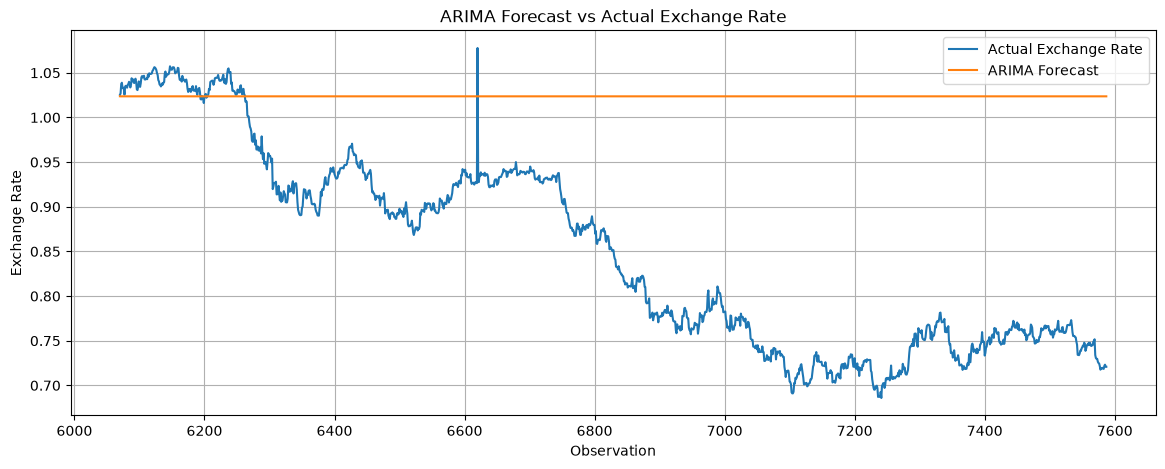

In [63]:
# Compare actual values with ARIMA forecast

plt.figure(figsize=(14, 5))

plt.plot(test.index, test, label="Actual Exchange Rate")
plt.plot(arima_forecast.index, arima_forecast, label="ARIMA Forecast")

plt.title("ARIMA Forecast vs Actual Exchange Rate")
plt.xlabel("Observation")
plt.ylabel("Exchange Rate")

plt.legend()
plt.grid(True)

plt.show()

## Exponential Smoothing

Exponential Smoothing is used as a second forecasting approach. The model is fitted on the training data and used to forecast the same testing period as the ARIMA model.

In [64]:
from statsmodels.tsa.holtwinters import Holt

In [65]:
# Fit Holt's Exponential Smoothing model on the training data

holt_model = Holt(train, initialization_method="estimated")
holt_result = holt_model.fit(optimized=True)

print(holt_result.summary())

                              Holt Model Results                              
Dep. Variable:                Ex_rate   No. Observations:                 6070
Model:                           Holt   SSE                              0.199
Optimized:                       True   AIC                         -62655.663
Trend:                       Additive   BIC                         -62628.819
Seasonal:                        None   AICC                        -62655.650
Seasonal Periods:                None   Date:                 Fri, 28 Aug 2026
Box-Cox:                        False   Time:                         10:35:55
Box-Cox Coeff.:                  None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            0.9428891                alpha                 True
smoothing_trend             0.000000                

In [66]:
# Forecast the testing period using Exponential Smoothing

holt_forecast = holt_result.forecast(steps=len(test))

# Keep the same index as the test data
holt_forecast.index = test.index

print("Number of forecasted values:", len(holt_forecast))

display(holt_forecast.head())

Number of forecasted values: 1518


6070    1.023582
6071    1.023621
6072    1.023661
6073    1.023700
6074    1.023739
dtype: float64

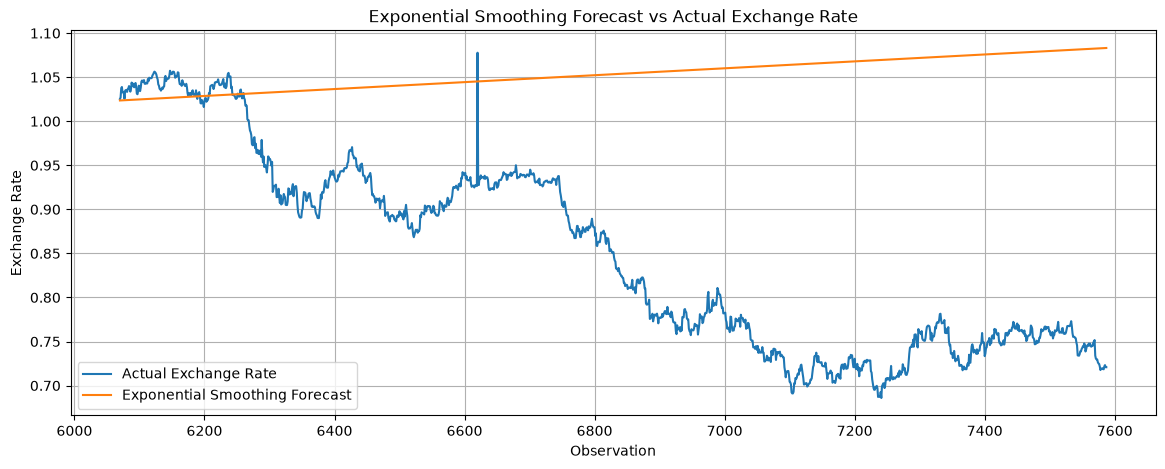

In [67]:
# Compare actual values with Exponential Smoothing forecast

plt.figure(figsize=(14, 5))

plt.plot(test.index, test, label="Actual Exchange Rate")
plt.plot(holt_forecast.index, holt_forecast, label="Exponential Smoothing Forecast")

plt.title("Exponential Smoothing Forecast vs Actual Exchange Rate")
plt.xlabel("Observation")
plt.ylabel("Exchange Rate")

plt.legend()
plt.grid(True)

plt.show()

## Part 3: Evaluation and Comparison

### Error Metrics

The ARIMA and Exponential Smoothing forecasts are evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and Mean Absolute Percentage Error (MAPE).

In [68]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [69]:
# Calculate error metrics for ARIMA

arima_mae = mean_absolute_error(test, arima_forecast)

arima_rmse = np.sqrt(
    mean_squared_error(test, arima_forecast)
)

arima_mape = np.mean(
    np.abs((test - arima_forecast) / test)
) * 100


# Calculate error metrics for Exponential Smoothing

holt_mae = mean_absolute_error(test, holt_forecast)

holt_rmse = np.sqrt(
    mean_squared_error(test, holt_forecast)
)

holt_mape = np.mean(
    np.abs((test - holt_forecast) / test)
) * 100


print("ARIMA(1,1,1)")
print("MAE :", arima_mae)
print("RMSE:", arima_rmse)
print("MAPE:", arima_mape, "%")

print("\nExponential Smoothing")
print("MAE :", holt_mae)
print("RMSE:", holt_rmse)
print("MAPE:", holt_mape, "%")

ARIMA(1,1,1)
MAE : 0.17770970449121345
RMSE: 0.2054366965966928
MAPE: 22.797966173811552 %

Exponential Smoothing
MAE : 0.20659618979165734
RMSE: 0.23910443004601642
MAPE: 26.508663625599837 %


In [70]:
# Create a comparison table

results = pd.DataFrame({
    "Model": [
        "ARIMA(1,1,1)",
        "Exponential Smoothing"
    ],
    "MAE": [
        arima_mae,
        holt_mae
    ],
    "RMSE": [
        arima_rmse,
        holt_rmse
    ],
    "MAPE (%)": [
        arima_mape,
        holt_mape
    ]
})

display(results.round(6))

,Model,MAE,RMSE,MAPE (%)
0,"ARIMA(1,1,1)",0.177710,0.205437,22.797966
1,Exponential Smoothing,0.206596,0.239104,26.508664


## Model Comparison

The performance of ARIMA(1,1,1) and Exponential Smoothing was compared using MAE, RMSE, and MAPE.

ARIMA(1,1,1) achieved a MAE of 0.177710, RMSE of 0.205437, and MAPE of 22.797966%.

Exponential Smoothing achieved a MAE of 0.206596, RMSE of 0.239104, and MAPE of 26.508664%.

ARIMA(1,1,1) performed better than Exponential Smoothing because it produced lower values for all three error metrics.

ARIMA is advantageous because it can model autocorrelation and differencing in the time series. However, ARIMA requires parameter selection and can be more complex to build and interpret.

Exponential Smoothing is simpler and useful for modeling level and trend, but in this dataset it was less accurate than ARIMA based on the evaluation metrics.

### Forecast Comparison

The forecasts from ARIMA and Exponential Smoothing are compared with the actual exchange-rate values over the testing period.

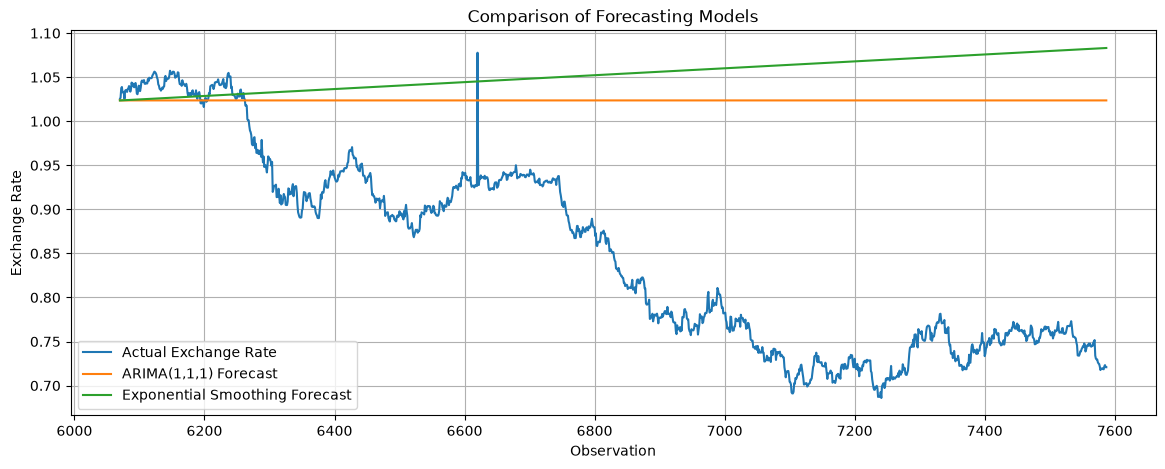

In [71]:
# Compare both forecasting models with the actual values

plt.figure(figsize=(14, 5))

plt.plot(test.index, test, label="Actual Exchange Rate")
plt.plot(arima_forecast.index, arima_forecast, label="ARIMA(1,1,1) Forecast")
plt.plot(holt_forecast.index, holt_forecast, label="Exponential Smoothing Forecast")

plt.title("Comparison of Forecasting Models")
plt.xlabel("Observation")
plt.ylabel("Exchange Rate")

plt.legend()
plt.grid(True)

plt.show()

## Conclusion

In this analysis, historical USD to Australian Dollar exchange-rate data was analyzed using time series techniques.

The data was explored and missing values were handled using forward fill (`ffill`) as part of the preprocessing step. The Augmented Dickey-Fuller test showed that the original series was non-stationary. First-order differencing was therefore applied, after which the series became stationary.

ACF and PACF plots were used to guide the selection of the ARIMA parameters. An ARIMA(1,1,1) model was then fitted and evaluated through residual diagnostics. The Ljung-Box test indicated no significant residual autocorrelation at the tested lag.

ARIMA(1,1,1) and Exponential Smoothing were both used to forecast the testing period. Their performance was evaluated using MAE, RMSE, and MAPE.

ARIMA(1,1,1) achieved lower values for all three metrics:

- MAE: 0.177710
- RMSE: 0.205437
- MAPE: 22.797966%

Exponential Smoothing achieved:

- MAE: 0.206596
- RMSE: 0.239104
- MAPE: 26.508664%

Therefore, based on the evaluation results, ARIMA(1,1,1) performed better than Exponential Smoothing for forecasting the exchange rate in this dataset.